# Retail Sales & Customer Analytics

## Project Objective
Analyze multi-year online retail transaction data to identify revenue trends, top-performing products, key markets, high-value customers, and customer purchase behavior.

This notebook covers:
- Data loading
- Data cleaning
- Feature engineering
- Exploratory Data Analysis (EDA)
- Key business insights

## 1. Import Libraries

In [23]:
# Import required libraries
import os
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Raw Dataset

The raw Excel file contains two sheets. Both sheets are loaded and combined into one DataFrame for analysis.

In [24]:
# Define file paths
file_path = r"C:\Users\sahil\OneDrive\Documents\Project\Retail Project\Data\Raw\online_retail_II.xlsx"

# Check available sheets in the Excel file
xls = pd.ExcelFile(file_path)
print("Sheets:", xls.sheet_names)

# Load and combine all sheets into one DataFrame
df_dict = pd.read_excel(file_path, sheet_name=None)
df = pd.concat(df_dict.values(), ignore_index=True)

# Initial inspection
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Sheets: ['Year 2009-2010', 'Year 2010-2011']
Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Data Cleaning

The raw dataset contains missing customer IDs, cancelled/returned transactions, and inconsistent column naming. These issues must be fixed before analysis.

In [25]:
# Standardize column names by removing extra spaces and replacing spaces with underscores
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Check missing values before cleaning
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer_ID    243007
Country             0
dtype: int64

In [26]:
# Remove rows where Customer_ID is missing
# Customer_ID is required for customer-level analysis and segmentation
df = df.dropna(subset=['Customer_ID'])

# Remove cancelled/returned transactions and invalid prices
# Negative Quantity usually indicates product returns or cancellations
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Remove non-product transaction rows
# These rows represent charges, postage, manual adjustments, or non-merchandise entries
non_product_codes = ['POST', 'DOT', 'M', 'BANK CHARGES', 'C2']
df = df[~df['StockCode'].astype(str).isin(non_product_codes)]
df = df[~df['Description'].astype(str).str.upper().str.contains('POSTAGE|MANUAL|BANK CHARGES|DOTCOM', na=False)]

# Convert InvoiceDate into datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create revenue column at row/product level
df['TotalPrice'] = df['Quantity'] * df['Price']

# Extract year and month for time-based analysis
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)
display(df.head())

Shape after cleaning: (776645, 11)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,TotalPrice,Year,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12


## 4. Filter Partial Year Data

The dataset includes only partial data for 2009. Since partial-year data can distort trend and seasonality analysis, 2009 is excluded from the final analysis.

In [28]:
# Check row count by year before filtering
df['Year'].value_counts().sort_index()

Year
2009     30213
2010    380849
2011    365583
Name: count, dtype: int64

In [29]:
# Keep only complete analysis years
df = df[df['Year'] >= 2010]

# Confirm final years included
df['Year'].value_counts().sort_index()

Year
2010    380849
2011    365583
Name: count, dtype: int64

## 5. Save Cleaned Dataset

The final cleaned dataset is saved for SQL, Excel, and Tableau analysis.

In [30]:
# Create processed data folder if it does not exist
os.makedirs(r"C:\Users\sahil\OneDrive\Documents\Project\Retail Project\data\processed", exist_ok=True)

# Save final cleaned dataset
df.to_csv(
    r"C:\Users\sahil\OneDrive\Documents\Project\Retail Project\data\processed\retail_cleaned.csv",
    index=False
)

# Reload to verify saved file
df_check = pd.read_csv(
    r"C:\Users\sahil\OneDrive\Documents\Project\Retail Project\data\processed\retail_cleaned.csv"
)

print("Saved file shape:", df_check.shape)
print(df_check['Year'].value_counts().sort_index())

Saved file shape: (746432, 11)
Year
2010    380849
2011    365583
Name: count, dtype: int64


## 6. Basic KPI Checks

Before EDA, key order-level metrics are calculated to avoid confusing product-level rows with actual customer orders.

In [31]:
# Total unique orders
total_orders = df['Invoice'].nunique()

# Calculate order-level revenue by aggregating product lines under each invoice
order_value = df.groupby('Invoice')['TotalPrice'].sum()

# Average Order Value
avg_order_value = order_value.mean()

print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Orders: 35142
Average Order Value: 466.5479149450799


## 7. EDA Part 1 — Monthly Revenue Trend

Business question: How does revenue change over time, and are there seasonal patterns?

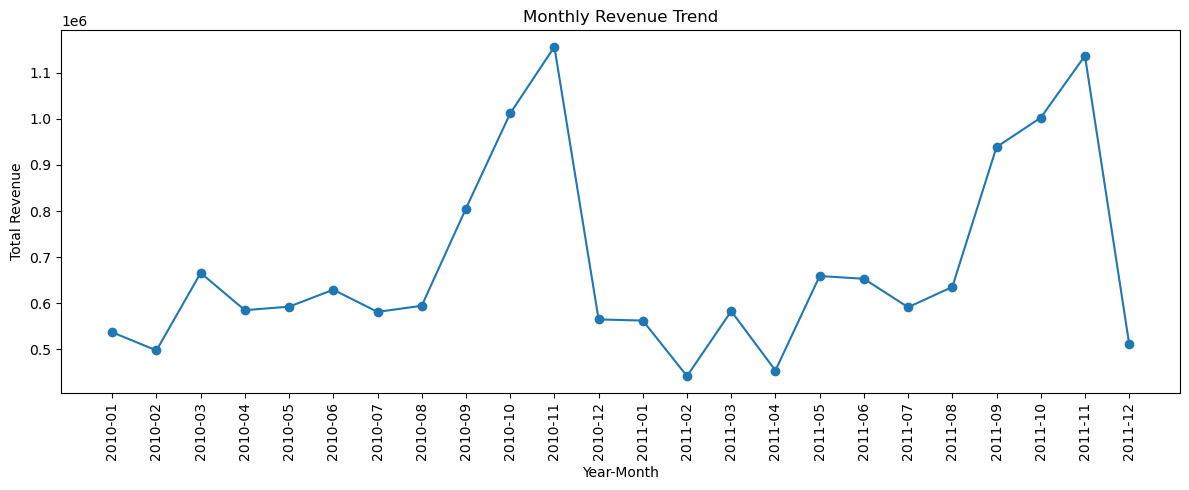

In [32]:
# Group data by Year and Month, then calculate total revenue for each month
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()

# Create a readable Year-Month label for charting
monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + "-" + monthly_sales['Month'].astype(str).str.zfill(2)

# Plot monthly revenue trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['TotalPrice'], marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Insight — Monthly Revenue Trend

Revenue shows a consistent upward trend from mid-year and peaks between October and November across both years, indicating strong seasonal demand aligned with pre-holiday shopping periods. The decline after the peak highlights dependence on seasonal sales cycles.

## 8. EDA Part 2 — Top Products by Revenue

Business question: Which products generate the most revenue?

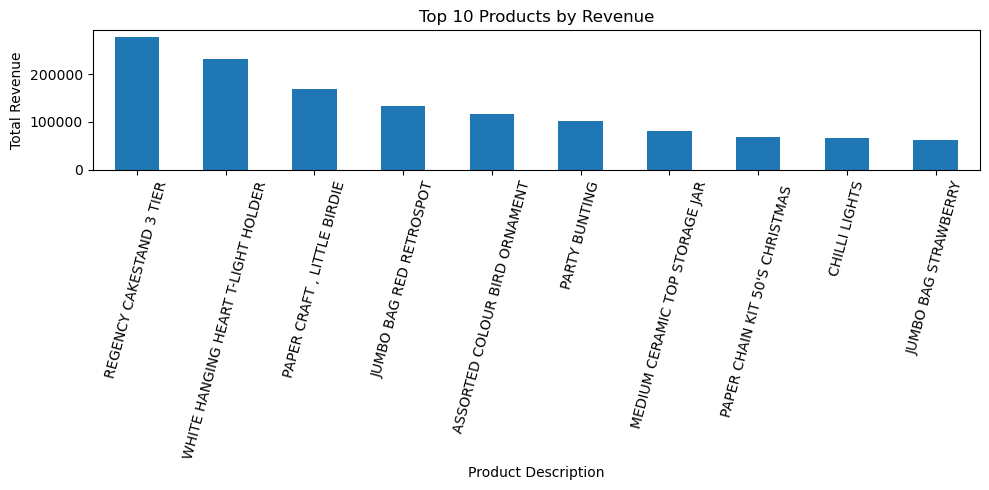

In [33]:
# Calculate total revenue generated by each product
top_products = (
    df.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot top 10 products by revenue
top_products.plot(kind='bar', figsize=(10, 5))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Description")
plt.ylabel("Total Revenue")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### Insight — Top Products

Revenue is concentrated among a small set of high-performing products. Many top items are decorative, gifting, or occasion-based products, suggesting that revenue is influenced by seasonal and event-driven demand.

## 9. EDA Part 3 — Top Countries by Revenue

Business question: Which markets contribute the most revenue?

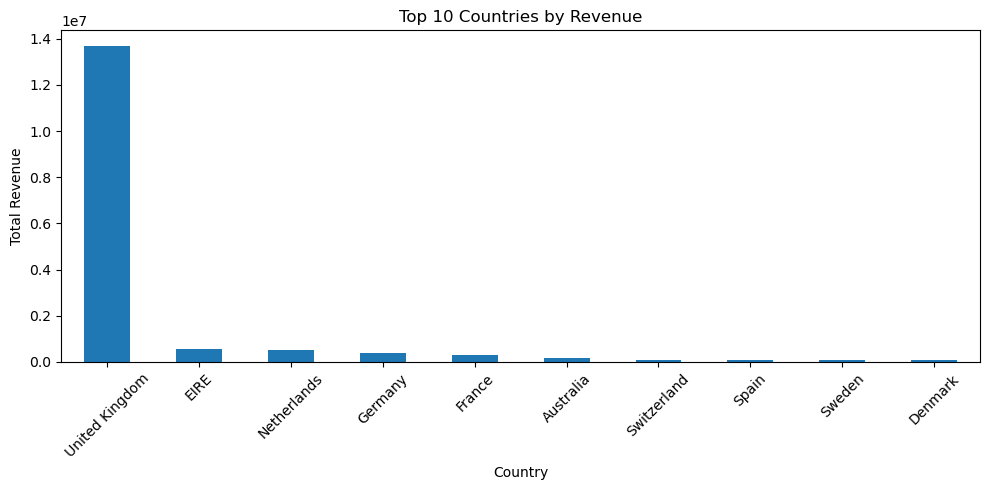

In [34]:
# Group data by Country and calculate total revenue for each country
top_countries = (
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot top 10 countries by revenue
top_countries.plot(kind='bar', figsize=(10, 5))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight — Top Countries

Revenue is highly concentrated in the United Kingdom, which significantly outperforms all other countries. This indicates heavy geographic dependency, while lower revenue from other regions suggests potential international growth opportunities.

## 10. EDA Part 4 — Top Customers by Revenue

Business question: Which customers drive the most revenue?

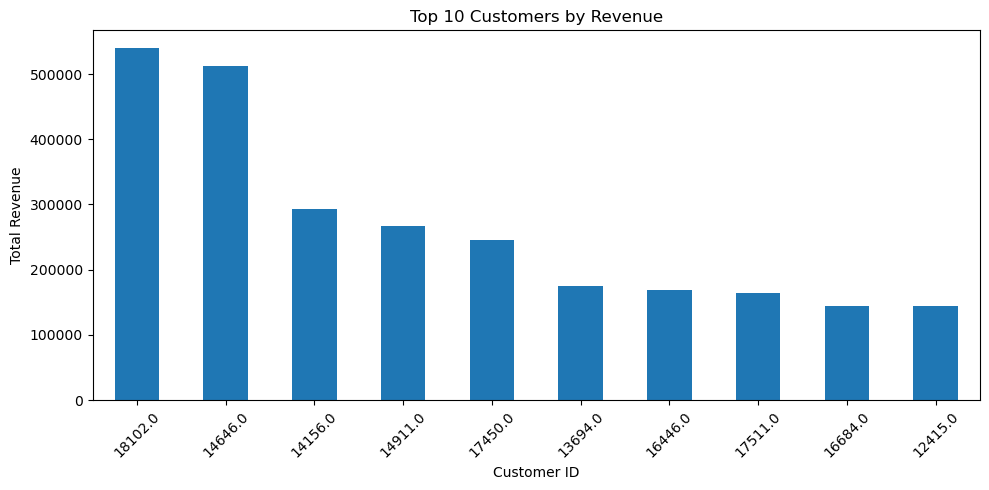

In [35]:
# Calculate total revenue generated by each customer
top_customers = (
    df.groupby('Customer_ID')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot top 10 customers by revenue
top_customers.plot(kind='bar', figsize=(10, 5))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight — Top Customers

A small group of customers contributes a large share of revenue, showing the presence of high-value customer segments. Retaining these customers is important because the business may be exposed to revenue risk if major customers reduce purchasing.

## 11. EDA Part 5 — Customer Behavior: Repeat vs One-Time Customers

Business question: Are customers returning, or is the business heavily dependent on one-time buyers?

In [36]:
# Count number of unique orders for each customer
customer_orders = df.groupby('Customer_ID')['Invoice'].nunique()

# Customers with more than one order are repeat customers
repeat_customers = (customer_orders > 1).sum()

# Customers with exactly one order are one-time customers
one_time_customers = (customer_orders == 1).sum()

print("Repeat Customers:", repeat_customers)
print("One-time Customers:", one_time_customers)

Repeat Customers: 4163
One-time Customers: 1609


### Insight — Customer Behavior

Repeat and one-time customer counts help evaluate customer retention. If one-time customers are high, the business should focus on retention strategies such as loyalty programs, targeted offers, and customer reactivation campaigns.

## 12. Final Business Insights

- Revenue increases from mid-year and peaks around October–November, showing strong seasonal demand.
- Revenue is highly dependent on the United Kingdom, creating geographic concentration risk.
- A small group of products contributes heavily to revenue, indicating product concentration.
- Top customers generate a disproportionate share of revenue, making customer retention important.
- Customer behavior analysis should guide loyalty and retention strategies.